In [20]:
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

from rk45_solver import rk45
from animation import animate_pendulum
from jax.experimental.ode import odeint

from IPython.display import HTML
from functools import partial

In [13]:
def rhs(y, t, PENDULUM_MASS, CART_MASS, LEN, FORCE):
    GRAVITY = 9.81

    x = y[0]
    theta = y[1]
    v = y[2]
    omega = y[3]

    v_dot = (FORCE + (GRAVITY * jnp.cos(theta) - LEN * omega**2) * PENDULUM_MASS * jnp.sin(theta)) / (CART_MASS + PENDULUM_MASS * jnp.sin(theta)**2)
    omega_dot = (FORCE * jnp.cos(theta) + GRAVITY * CART_MASS * jnp.sin(theta) + (GRAVITY - LEN * jnp.cos(theta) * omega**2) * PENDULUM_MASS * jnp.sin(theta)) / (LEN * (CART_MASS + PENDULUM_MASS * jnp.sin(theta)**2))

    return jnp.array([v, omega, v_dot, omega_dot])

In [6]:
y0 = jnp.array([0, jnp.pi / 2, 0, 0])
ts = jnp.linspace(0, 10, 100)

rhs_ = lambda y, t: rhs(y, t, 1, 10, 10)
ys = rk45(rhs_, ts, y0, h0=0.001)

TypeError: rhs() takes 3 positional arguments but 5 were given

In [4]:
def rhs(y, t, lmbda):
    return -lmbda * y

ts = jnp.linspace(1, 10, 100)
y0 = 1.

ys_true = odeint(rhs, y0, ts, 1)

def loss(lmbda):
    ys = odeint(rhs, y0, ts, lmbda)

    return jnp.sum((ys - ys_true)**2)

In [5]:
rate = 0.2
lmbda_guess = 10.
loss_val_grad = jax.value_and_grad(loss)
for _ in range(1000):
    val, grad = loss_val_grad(lmbda_guess)
    lmbda_guess = lmbda_guess - grad * rate


In [183]:
args = {
    'PENDULUM_MASS': 1.,
    'CART_MASS': 1.,
    'LEN': 1.,
    'FORCE': 0.
}

ts = jnp.linspace(0, 10, 100)
y0 = jnp.array([0, 0.1, 0, 0], dtype=jnp.float32)

ys = odeint(rhs, y0, ts, *args.values())

In [174]:
anim = animate_pendulum(ts, ys, 1.)
plt.close()
HTML(anim.to_jshtml())

In [9]:
def loss(F, y, step, args):
    soln = odeint(rhs, y, step, *args.values(), F)
    thetas = soln[-1,1]

    return thetas**2

grad_loss = jax.grad(loss, argnums=0)

In [123]:
args = {
    'PENDULUM_MASS': 0.1,
    'CART_MASS': 1.,
    'LEN': 1.,
}

rate = 50_000

ts = jnp.linspace(0, 5, 5000)
rolled_ts = jnp.roll(ts, -1)
pairs = jnp.stack((ts, rolled_ts), axis=1)[:-1]

y0 = jnp.array([0, 0.8 * jnp.pi, 0, 0], dtype=jnp.float32)
F0 = -1.

def scan_fun(carry, pair):
    y, F = carry
    rate = jnp.exp(1e2 * loss(F, y, pair, args))
    def body_fun(i, F):
        grad = grad_loss(F, y, pair, args)
        F -= rate * grad

        return F

    F = jax.lax.fori_loop(0, 10, body_fun, F)
    y = odeint(rhs, y, pair, *args.values(), F)
    carry = y[1], F

    return carry, carry

from jax.config import config
config.update('jax_disable_jit', False)

init_carry = y0, F0
carry, (ys, Fs) = jax.lax.scan(scan_fun, init_carry, pairs)

Fs = jnp.insert(Fs, 0, F0)

In [127]:
Fs

DeviceArray([-1., nan, nan, ..., nan, nan, nan], dtype=float32)

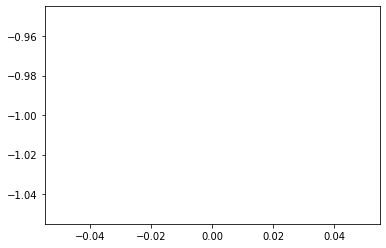

In [124]:
plt.plot(ts, Fs)
plt.show()

In [126]:
anim = animate_pendulum(ts[::50], ys[::50], 1.)
plt.close()

HTML(anim.to_jshtml())

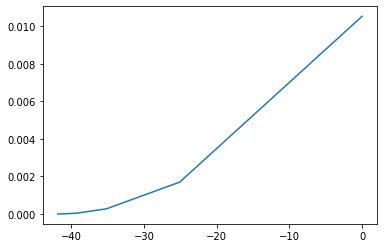

In [108]:
y0 = jnp.array([0, 0.1, 0, 0], dtype=jnp.float32)
ts = jnp.array([0, 0.07])
F0 = 0

rate = 50_000
amount = 10
fig, ax = plt.subplots()

Fs = jnp.zeros(amount)
Fs = Fs.at[0].set(F0)

for i in range(amount):
    F = Fs[i]
    grad = grad_loss(F, y0, ts, args)
    F -= rate * grad
    Fs = Fs.at[i + 1].set(F)

loss_vals = [loss(F, y0, ts, args) for F in Fs]

plt.plot(Fs, loss_vals)
